## 1. What is Data Analysis?

Data Analysis is the process of collecting, cleaning, transforming, exploring, and interpreting data to obtain useful information and support decision-making.

### Main Steps

1. Data Collection
2. Data Cleaning
3. Data Transformation
4. Exploratory Data Analysis
5. Statistical Analysis
6. Data Visualization
7. Interpretation
8. Decision Making

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import requests
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Science Project Steps

A typical Data Science project follows these steps:

1. Problem Definition
2. Data Collection
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Engineering
7. Feature Selection
8. Model Building
9. Model Evaluation
10. Deployment

## 3. Machine Learning Problem Statement

The objective is to predict whether a customer will churn based on demographic, purchasing, and engagement information.

### Target Variable

`Churn`

- `0` = Customer does not churn
- `1` = Customer churns

This is a **Binary Classification** problem.

## 4. What are Tensors?

A tensor is a multidimensional numerical data structure.

- 0-D Tensor → Scalar
- 1-D Tensor → Vector
- 2-D Tensor → Matrix
- 3-D Tensor → Three-dimensional array

NumPy arrays can be used to create and manipulate tensors.

In [2]:
# 0-D Tensor
tensor_0d = np.array(10)

# 1-D Tensor
tensor_1d = np.array([10, 20, 30, 40])

# 2-D Tensor
tensor_2d = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

# 3-D Tensor
tensor_3d = np.array([
    [[1, 2], [3, 4]],
    [[5, 6], [7, 8]]
])

print("0-D Tensor:")
print(tensor_0d)
print("Shape:", tensor_0d.shape)

print("\n1-D Tensor:")
print(tensor_1d)
print("Shape:", tensor_1d.shape)

print("\n2-D Tensor:")
print(tensor_2d)
print("Shape:", tensor_2d.shape)

print("\n3-D Tensor:")
print(tensor_3d)
print("Shape:", tensor_3d.shape)

0-D Tensor:
10
Shape: ()

1-D Tensor:
[10 20 30 40]
Shape: (4,)

2-D Tensor:
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)

3-D Tensor:
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
Shape: (2, 2, 2)


# Part B: Data Acquisition

The project requires data acquisition from multiple sources.

The main customer dataset is provided as a CSV file. For demonstration purposes, selected information from the same customer dataset will also be stored and loaded as JSON and SQL data.

An API request is demonstrated separately to show how external data can be acquired.

In [3]:
df = pd.read_csv("customer_data_profiler.csv")

print("Dataset loaded successfully.")

print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (301, 10)


,CustomerID,Age,Gender,Income,Purchases,Purchase_Frequency,Average_Purchase_Value,Tenure_Years,Engagement_Score,Churn
0,1001,56.0,female,109112.0,22.0,1,9626,2.1,39.0,1
1,1002,46.0,Male,117203.0,30.0,14,3542,1.5,36.0,0
2,1003,32.0,F,31130.0,17.0,3,4997,6.5,97.0,1
3,1004,60.0,M,107508.0,26.0,2,1966,7.2,36.0,0
4,1005,25.0,female,80566.0,36.0,2,4061,0.8,3.0,1


In [4]:
print("Dataset Columns:")
print(df.columns.tolist())

Dataset Columns:
['CustomerID', 'Age', 'Gender', 'Income', 'Purchases', 'Purchase_Frequency', 'Average_Purchase_Value', 'Tenure_Years', 'Engagement_Score', 'Churn']


## CSV Data Acquisition

The customer dataset is loaded using Pandas `read_csv()`.

The dataset contains customer demographic, purchasing, engagement, and churn information.

In [5]:
json_data = df.drop_duplicates(
    subset="CustomerID"
)[[
    "CustomerID",
    "Purchases",
    "Purchase_Frequency",
    "Average_Purchase_Value"
]]

json_data.to_json(
    "customer_purchases.json",
    orient="records",
    indent=4
)

print("JSON file created successfully.")

JSON file created successfully.


In [6]:
df_json = pd.read_json(
    "customer_purchases.json"
)

print("JSON Data:")
display(df_json.head())

JSON Data:


,CustomerID,Purchases,Purchase_Frequency,Average_Purchase_Value
0,1001,22.0,1,9626
1,1002,30.0,14,3542
2,1003,17.0,3,4997
3,1004,26.0,2,1966
4,1005,36.0,2,4061


## SQL Data Acquisition

SQL databases are commonly used to store structured business data.

A SQLite database is created from the customer dataset and queried using SQL.

In [7]:
sql_data = df.drop_duplicates(
    subset="CustomerID"
)[[
    "CustomerID",
    "Tenure_Years",
    "Engagement_Score"
]]

connection = sqlite3.connect(
    "customer_database.db"
)

sql_data.to_sql(
    "customer_engagement",
    connection,
    if_exists="replace",
    index=False
)

print("SQL database created successfully.")

SQL database created successfully.


In [8]:
query = """
SELECT
    CustomerID,
    Tenure_Years,
    Engagement_Score
FROM customer_engagement
"""

df_sql = pd.read_sql_query(
    query,
    connection
)

display(df_sql.head())

connection.close()

,CustomerID,Tenure_Years,Engagement_Score
0,1001,2.1,39.0
1,1002,1.5,36.0
2,1003,6.5,97.0
3,1004,7.2,36.0
4,1005,0.8,3.0


## API Data Acquisition

An API allows applications to communicate with external services and retrieve data.

The following example demonstrates retrieving JSON data from a REST API.

In [9]:
api_url = "https://jsonplaceholder.typicode.com/users"

try:
    response = requests.get(
        api_url,
        timeout=10
    )

    if response.status_code == 200:
        api_data = response.json()

        df_api = pd.DataFrame(api_data)

        print("API data fetched successfully.")

        display(df_api.head())

    else:
        print(
            "API request failed with status:",
            response.status_code
        )

except Exception as e:
    print("API unavailable:", e)

API data fetched successfully.


,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


## Combining Data from Multiple Sources

The CSV dataset is the primary customer dataset.

JSON and SQL data are derived from the same customer records and can be matched using `CustomerID`.

The API section demonstrates external data acquisition but is not merged with the customer dataset because it contains unrelated demonstration data.

In [10]:
df_sources = df.drop_duplicates(
    subset="CustomerID"
).copy()

df_sources = df_sources.merge(
    df_json,
    on="CustomerID",
    how="left"
)

df_sources = df_sources.merge(
    df_sql,
    on="CustomerID",
    how="left",
    suffixes=("", "_sql")
)

print("Combined Dataset Shape:")
print(df_sources.shape)

display(df_sources.head())

Combined Dataset Shape:
(300, 15)


,CustomerID,Age,Gender,Income,Purchases_x,Purchase_Frequency_x,Average_Purchase_Value_x,Tenure_Years,Engagement_Score,Churn,Purchases_y,Purchase_Frequency_y,Average_Purchase_Value_y,Tenure_Years_sql,Engagement_Score_sql
0,1001,56.0,female,109112.0,22.0,1,9626,2.1,39.0,1,22.0,1,9626,2.1,39.0
1,1002,46.0,Male,117203.0,30.0,14,3542,1.5,36.0,0,30.0,14,3542,1.5,36.0
2,1003,32.0,F,31130.0,17.0,3,4997,6.5,97.0,1,17.0,3,4997,6.5,97.0
3,1004,60.0,M,107508.0,26.0,2,1966,7.2,36.0,0,26.0,2,1966,7.2,36.0
4,1005,25.0,female,80566.0,36.0,2,4061,0.8,3.0,1,36.0,2,4061,0.8,3.0


# Part C: Data Understanding and Cleaning

The dataset is explored using:

- `head()`
- `info()`
- `describe()`

Missing values and duplicate records are also identified.

In [11]:
display(df.head(10))

,CustomerID,Age,Gender,Income,Purchases,Purchase_Frequency,Average_Purchase_Value,Tenure_Years,Engagement_Score,Churn
0,1001,56.0,female,109112.0,22.0,1,9626,2.1,39.0,1
1,1002,46.0,Male,117203.0,30.0,14,3542,1.5,36.0,0
2,1003,32.0,F,31130.0,17.0,3,4997,6.5,97.0,1
3,1004,60.0,M,107508.0,26.0,2,1966,7.2,36.0,0
4,1005,25.0,female,80566.0,36.0,2,4061,0.8,3.0,1
5,1006,38.0,male,NaN,1.0,6,1114,9.4,73.0,0
6,1007,56.0,Male,47192.0,8.0,12,5892,1.0,8.0,0
7,1008,36.0,Male,21062.0,35.0,1,8193,5.6,97.0,0
8,1009,40.0,female,104076.0,15.0,2,9874,7.2,70.0,1
9,1010,28.0,male,109780.0,22.0,14,3723,8.8,41.0,1


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              301 non-null    int64  
 1   Age                     300 non-null    float64
 2   Gender                  300 non-null    str    
 3   Income                  300 non-null    float64
 4   Purchases               300 non-null    float64
 5   Purchase_Frequency      301 non-null    int64  
 6   Average_Purchase_Value  301 non-null    int64  
 7   Tenure_Years            301 non-null    float64
 8   Engagement_Score        300 non-null    float64
 9   Churn                   301 non-null    int64  
dtypes: float64(5), int64(4), str(1)
memory usage: 23.6 KB


In [13]:
display(
    df.describe(include="all").T
)   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,301.0,NaN,NaN,NaN,1150.053156,86.948359,1001.0,1075.0,1150.0,1225.0,1300.0
Age,300.0,NaN,NaN,NaN,40.72,13.595504,18.0,28.75,41.0,52.0,64.0
Gender,300,6,M,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,300.0,NaN,NaN,NaN,66869.493333,28250.805357,20384.0,43369.75,63106.5,91738.0,119835.0
Purchases,300.0,NaN,NaN,NaN,20.223333,11.380032,1.0,10.0,21.0,30.0,39.0
Purchase_Frequency,301.0,NaN,NaN,NaN,7.149502,3.970001,1.0,4.0,7.0,10.0,14.0
Average_Purchase_Value,301.0,NaN,NaN,NaN,5248.023256,2869.792835,501.0,2662.0,4994.0,7924.0,9977.0
Tenure_Years,301.0,NaN,NaN,NaN,5.347508,2.730684,0.5,2.8,5.5,7.5,10.0
Engagement_Score,300.0,NaN,NaN,NaN,47.516667,29.580281,1.0,21.0,45.0,73.0,99.0
Churn,301.0,NaN,NaN,NaN,0.372093,0.484168,0.0,0.0,0.0,1.0,1.0


## Missing Values

Missing values are observations where information is unavailable.

They must be identified and handled before machine learning.

In this project, numerical missing values will be replaced using the median and categorical missing values will be replaced using the mode.

In [14]:
missing_report = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(
    missing_report.sort_values(
        "Missing_Count",
        ascending=False
    )
)

,Missing_Count,Missing_Percentage
Age,1,0.33
Gender,1,0.33
Purchases,1,0.33
Income,1,0.33
Engagement_Score,1,0.33
CustomerID,0,0.00
Purchase_Frequency,0,0.00
Average_Purchase_Value,0,0.00
Tenure_Years,0,0.00
Churn,0,0.00


## Duplicate Records

Duplicate records are repeated observations.

Duplicates can produce incorrect statistics and may negatively affect machine learning models, so they should be identified and removed.

In [15]:
duplicate_count = df.duplicated().sum()

print(
    "Number of duplicate rows:",
    duplicate_count
)

Number of duplicate rows: 1


In [16]:
df = df.drop_duplicates().reset_index(
    drop=True
)

print(
    "Dataset shape after removing duplicates:",
    df.shape
)

Dataset shape after removing duplicates: (300, 10)


In [17]:
print(df.dtypes)

CustomerID                  int64
Age                       float64
Gender                        str
Income                    float64
Purchases                 float64
Purchase_Frequency          int64
Average_Purchase_Value      int64
Tenure_Years              float64
Engagement_Score          float64
Churn                       int64
dtype: object


In [18]:
numeric_columns = [
    "Age",
    "Income",
    "Purchases",
    "Purchase_Frequency",
    "Average_Purchase_Value",
    "Tenure_Years",
    "Engagement_Score",
    "Churn"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

df["CustomerID"] = pd.to_numeric(
    df["CustomerID"],
    errors="coerce"
)

print(df.dtypes)

CustomerID                  int64
Age                       float64
Gender                        str
Income                    float64
Purchases                 float64
Purchase_Frequency          int64
Average_Purchase_Value      int64
Tenure_Years              float64
Engagement_Score          float64
Churn                       int64
dtype: object


## Standardizing Categorical Data

The Gender column contains inconsistent values such as:

- `Male`
- `male`
- `M`
- `Female`
- `female`
- `F`

These values represent the same categories and therefore need to be standardized.

In [19]:
print("Gender values before cleaning:")

print(
    df["Gender"].value_counts(
        dropna=False
    )
)

Gender values before cleaning:
Gender
M         56
female    53
Male      51
Female    51
F         47
male      41
NaN        1
Name: count, dtype: int64


In [20]:
df["Gender"] = (
    df["Gender"]
    .astype("string")
    .str.strip()
    .str.lower()
)

df["Gender"] = df["Gender"].replace({
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female"
})

print("Gender values after standardization:")

print(
    df["Gender"].value_counts(
        dropna=False
    )
)

Gender values after standardization:
Gender
Female    151
Male      148
<NA>        1
Name: count, dtype: Int64


In [21]:
# Numerical columns
for column in numeric_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

# Gender
df["Gender"] = df["Gender"].fillna(
    df["Gender"].mode()[0]
)

print("Remaining missing values:")

print(df.isnull().sum())

Remaining missing values:
CustomerID                0
Age                       0
Gender                    0
Income                    0
Purchases                 0
Purchase_Frequency        0
Average_Purchase_Value    0
Tenure_Years              0
Engagement_Score          0
Churn                     0
dtype: int64


## Feature Engineering

Feature engineering is the process of creating meaningful new features from existing variables.

New customer behavior features will be created to make the dataset more useful for future machine learning.

In [22]:
df["Income_K"] = (
    df["Income"] / 1000
)

df["Total_Spending"] = (
    df["Purchases"] *
    df["Average_Purchase_Value"]
)

df["Purchase_Intensity"] = (
    df["Purchases"] /
    (df["Tenure_Years"] + 1)
)

df["Customer_Value"] = (
    df["Income"] * 0.3 +
    df["Total_Spending"] * 0.7
)

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 50, 100],
    labels=[
        "Young",
        "Adult",
        "Middle Age",
        "Senior"
    ]
)

display(df.head())

,CustomerID,Age,Gender,Income,Purchases,Purchase_Frequency,Average_Purchase_Value,Tenure_Years,Engagement_Score,Churn,Income_K,Total_Spending,Purchase_Intensity,Customer_Value,Age_Group
0,1001,56.0,Female,109112.0,22.0,1,9626,2.1,39.0,1,109.112,211772.0,7.096774,180974.0,Senior
1,1002,46.0,Male,117203.0,30.0,14,3542,1.5,36.0,0,117.203,106260.0,12.000000,109542.9,Middle Age
2,1003,32.0,Female,31130.0,17.0,3,4997,6.5,97.0,1,31.130,84949.0,2.266667,68803.3,Adult
3,1004,60.0,Male,107508.0,26.0,2,1966,7.2,36.0,0,107.508,51116.0,3.170732,68033.6,Senior
4,1005,25.0,Female,80566.0,36.0,2,4061,0.8,3.0,1,80.566,146196.0,20.000000,126507.0,Young


# Part D: Exploratory Data Analysis

## 8. Univariate Analysis

Univariate analysis examines one variable at a time.

The distributions of Age, Income, and Purchases are analyzed using histograms.

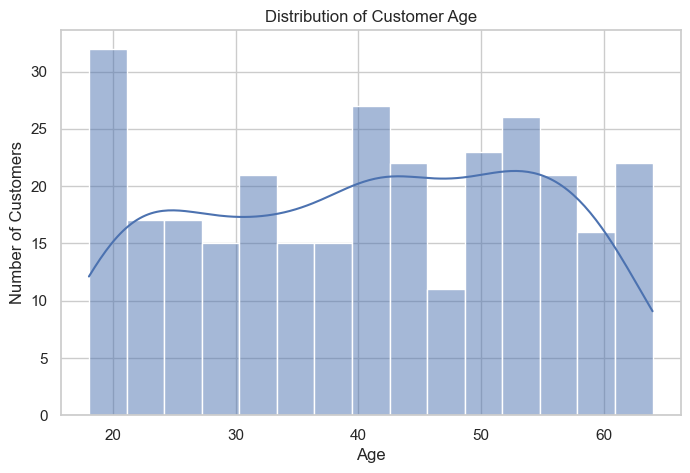

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Age"],
    bins=15,
    kde=True
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

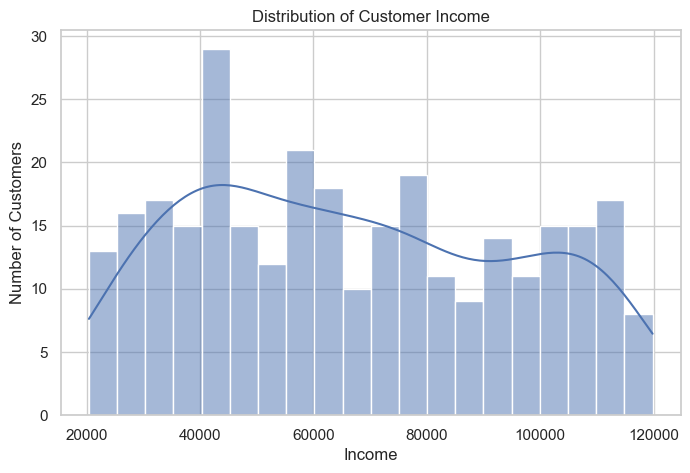

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Income"],
    bins=20,
    kde=True
)

plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

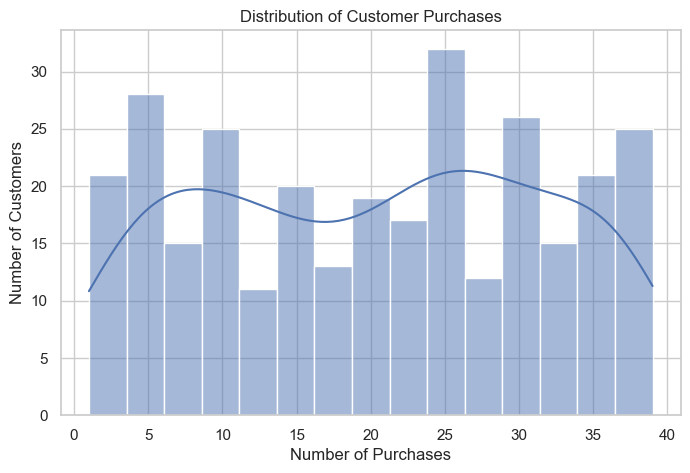

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Purchases"],
    bins=15,
    kde=True
)

plt.title("Distribution of Customer Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.show()

## 9. Bivariate Analysis

Bivariate analysis studies the relationship between two variables.

The following relationships are analyzed:

1. Gender and Purchases
2. Income and Churn

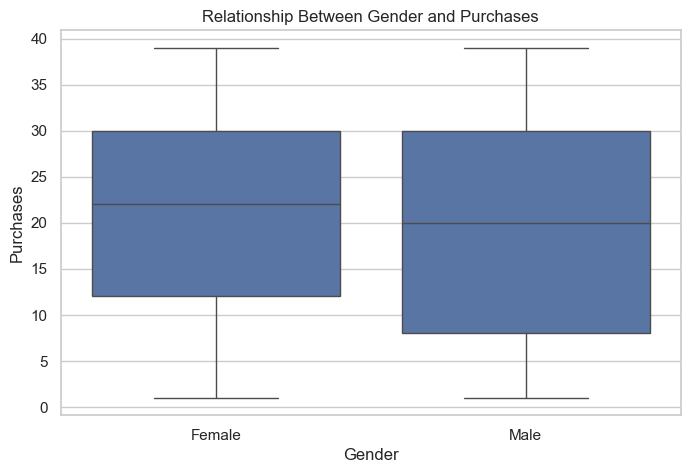

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Purchases"
)

plt.title("Relationship Between Gender and Purchases")
plt.xlabel("Gender")
plt.ylabel("Purchases")

plt.show()

In [27]:
gender_purchase = (
    df.groupby("Gender")["Purchases"]
    .mean()
    .reset_index()
)

display(gender_purchase)

,Gender,Purchases
0,Female,20.934211
1,Male,19.472973


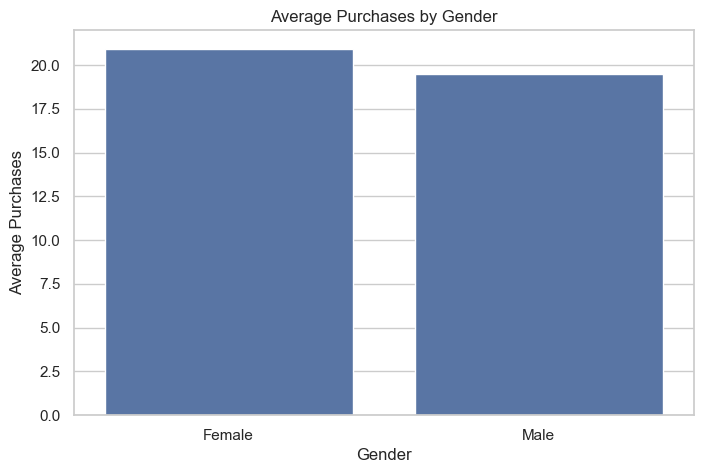

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=gender_purchase,
    x="Gender",
    y="Purchases"
)

plt.title("Average Purchases by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Purchases")

plt.show()

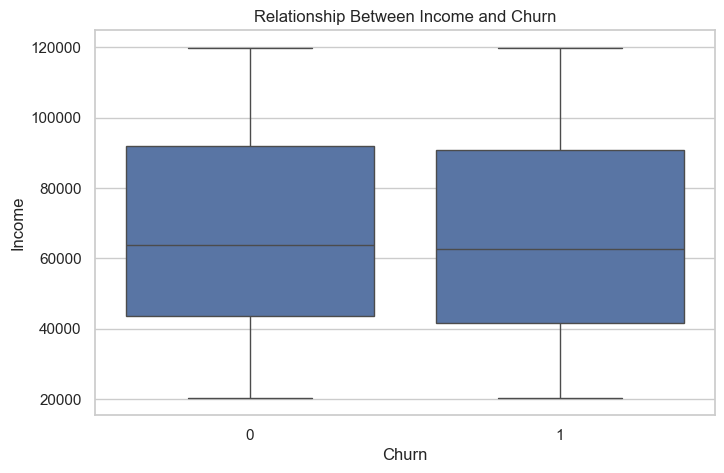

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Income"
)

plt.title("Relationship Between Income and Churn")
plt.xlabel("Churn")
plt.ylabel("Income")

plt.show()

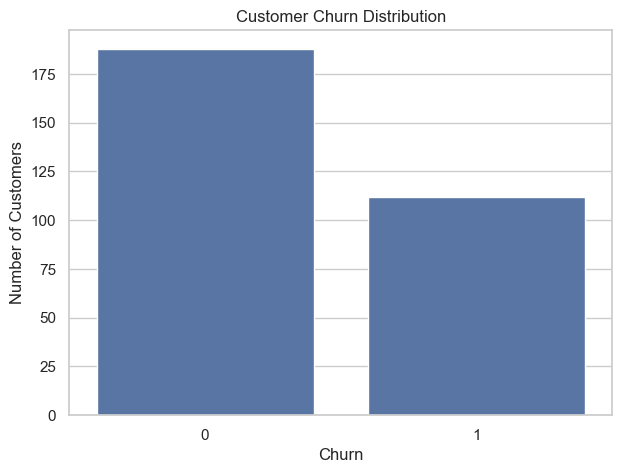

In [30]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## 10. Multivariate Analysis

Multivariate analysis examines relationships between three or more variables.

A correlation heatmap and pair plot are used to analyze relationships among numerical variables.

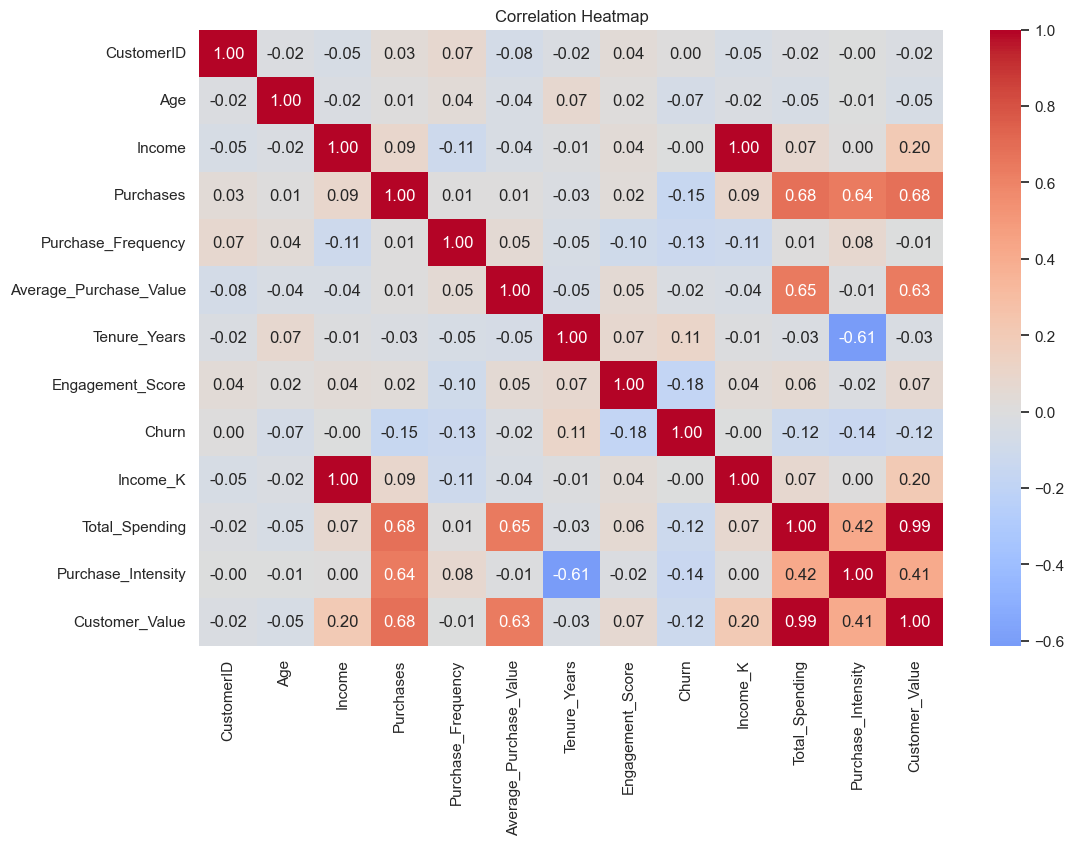

In [31]:
numeric_df = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

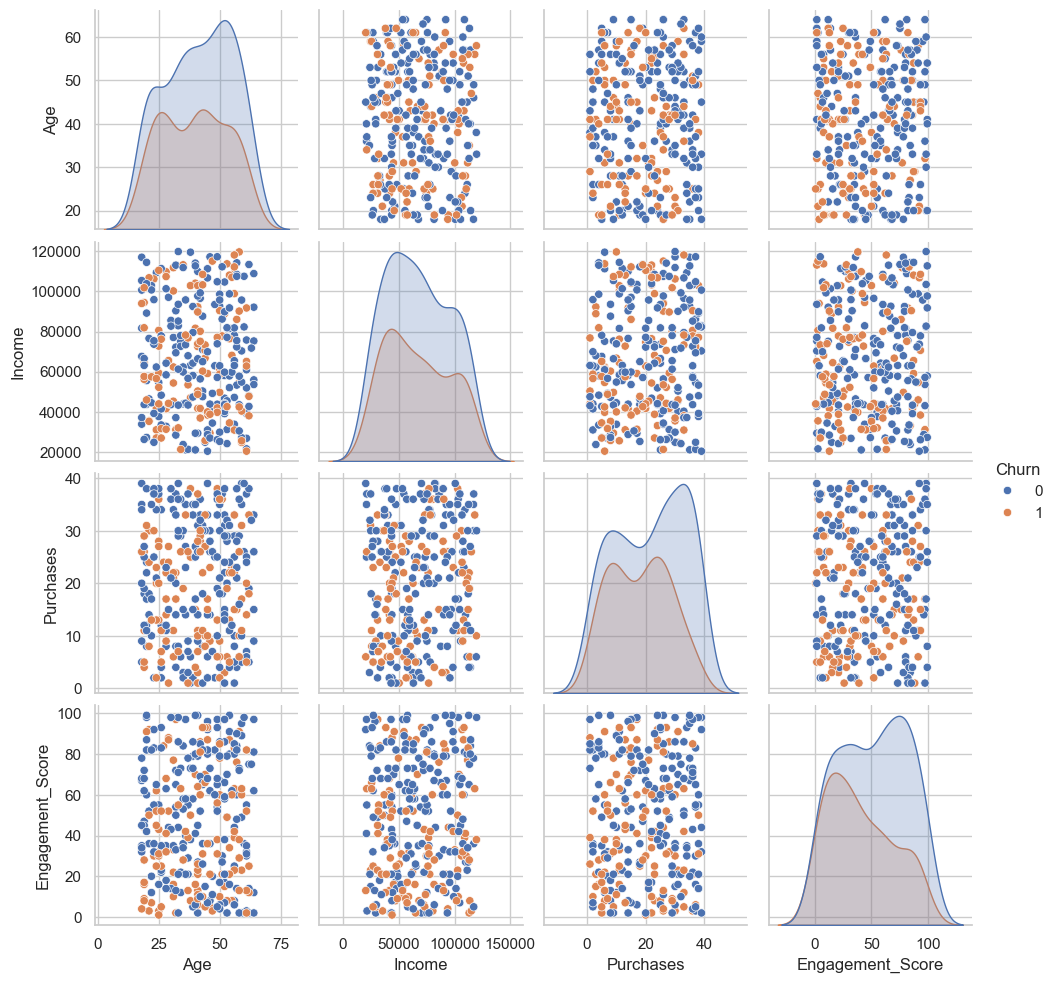

In [32]:
pair_columns = [
    "Age",
    "Income",
    "Purchases",
    "Engagement_Score",
    "Churn"
]

sns.pairplot(
    df[pair_columns],
    hue="Churn"
)

plt.show()

# Part E: Data Profiling

Data profiling is the process of examining a dataset to understand its structure, completeness, statistical characteristics, and quality.

The report includes:

- Missing values
- Descriptive statistics
- Data types
- Unique values
- Correlations
- Potential data-quality issues

In [33]:
profile_report = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2),
    "Unique_Values": df.nunique()
})

display(profile_report)

,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
CustomerID,int64,0,0.0,300
Age,float64,0,0.0,47
Gender,string,0,0.0,2
Income,float64,0,0.0,299
Purchases,float64,0,0.0,39
Purchase_Frequency,int64,0,0.0,14
Average_Purchase_Value,int64,0,0.0,298
Tenure_Years,float64,0,0.0,94
Engagement_Score,float64,0,0.0,90
Churn,int64,0,0.0,2


In [34]:
descriptive_statistics = df.describe(
    include="all"
).T

display(descriptive_statistics)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,300.0,NaN,NaN,NaN,1150.5,86.746758,1001.0,1075.75,1150.5,1225.25,1300.0
Age,300.0,NaN,NaN,NaN,40.79,13.542423,18.0,29.0,41.0,52.0,64.0
Gender,300,2,Female,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,300.0,NaN,NaN,NaN,66934.196667,28219.806216,20384.0,43369.75,63125.0,91738.0,119835.0
Purchases,300.0,NaN,NaN,NaN,20.213333,11.378021,1.0,10.0,21.0,30.0,39.0
Purchase_Frequency,300.0,NaN,NaN,NaN,7.13,3.962166,1.0,4.0,7.0,10.0,14.0
Average_Purchase_Value,300.0,NaN,NaN,NaN,5249.59,2874.458865,501.0,2656.25,4995.5,7927.25,9977.0
Tenure_Years,300.0,NaN,NaN,NaN,5.335333,2.727051,0.5,2.8,5.5,7.425,10.0
Engagement_Score,300.0,NaN,NaN,NaN,47.466667,29.571786,1.0,21.0,45.0,73.0,99.0
Churn,300.0,NaN,NaN,NaN,0.373333,0.484498,0.0,0.0,0.0,1.0,1.0


In [35]:
correlation_report = (
    df.select_dtypes(
        include=np.number
    ).corr()
)

display(correlation_report)

,CustomerID,Age,Income,Purchases,Purchase_Frequency,Average_Purchase_Value,Tenure_Years,Engagement_Score,Churn,Income_K,Total_Spending,Purchase_Intensity,Customer_Value
CustomerID,1.000000,-0.015435,-0.049836,0.033977,0.070426,-0.075511,-0.022536,0.037267,0.004218,-0.049836,-0.015357,-0.004301,-0.021538
Age,-0.015435,1.000000,-0.021694,0.005414,0.038220,-0.042512,0.074507,0.017215,-0.066510,-0.021694,-0.049122,-0.005806,-0.051052
Income,-0.049836,-0.021694,1.000000,0.088818,-0.111527,-0.040695,-0.008919,0.042723,-0.004600,1.000000,0.073765,0.000904,0.201994
Purchases,0.033977,0.005414,0.088818,1.000000,0.006208,0.006372,-0.026177,0.023887,-0.147362,0.088818,0.682320,0.638226,0.681587
Purchase_Frequency,0.070426,0.038220,-0.111527,0.006208,1.000000,0.053433,-0.047723,-0.095229,-0.131643,-0.111527,0.009568,0.077594,-0.005052
Average_Purchase_Value,-0.075511,-0.042512,-0.040695,0.006372,0.053433,1.000000,-0.053174,0.050984,-0.023518,-0.040695,0.647127,-0.008352,0.630246
Tenure_Years,-0.022536,0.074507,-0.008919,-0.026177,-0.047723,-0.053174,1.000000,0.074424,0.110979,-0.008919,-0.032626,-0.612244,-0.033196
Engagement_Score,0.037267,0.017215,0.042723,0.023887,-0.095229,0.050984,0.074424,1.000000,-0.183073,0.042723,0.061428,-0.016845,0.065861
Churn,0.004218,-0.066510,-0.004600,-0.147362,-0.131643,-0.023518,0.110979,-0.183073,1.000000,-0.004600,-0.119729,-0.143138,-0.118178
Income_K,-0.049836,-0.021694,1.000000,0.088818,-0.111527,-0.040695,-0.008919,0.042723,-0.004600,1.000000,0.073765,0.000904,0.201994


In [36]:
quality_warnings = []

# Missing values
for column in df.columns:

    missing_percentage = (
        df[column].isnull().mean() * 100
    )

    if missing_percentage > 0:
        quality_warnings.append(
            f"{column}: {missing_percentage:.2f}% missing values"
        )

# Duplicate rows
duplicates = df.duplicated().sum()

if duplicates > 0:
    quality_warnings.append(
        f"{duplicates} duplicate rows found"
    )

# Invalid age
invalid_age = (
    (df["Age"] < 0) |
    (df["Age"] > 100)
).sum()

if invalid_age > 0:
    quality_warnings.append(
        f"{invalid_age} invalid age values found"
    )

# Negative income
negative_income = (
    df["Income"] < 0
).sum()

if negative_income > 0:
    quality_warnings.append(
        f"{negative_income} negative income values found"
    )

print("DATA QUALITY REPORT")
print("=" * 40)

if len(quality_warnings) == 0:
    print("No major data quality issues detected.")
else:
    for warning in quality_warnings:
        print("WARNING:", warning)

DATA QUALITY REPORT
No major data quality issues detected.


# Final ML-Ready Dataset

After cleaning and feature engineering, the dataset is checked again.

The final dataset should contain:

- No duplicate records
- No missing values
- Correct data types
- Standardized categorical values
- Meaningful engineered features
- A clearly defined target variable

In [37]:
print("Final Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Final Dataset Shape:
(300, 15)

Missing Values:
CustomerID                0
Age                       0
Gender                    0
Income                    0
Purchases                 0
Purchase_Frequency        0
Average_Purchase_Value    0
Tenure_Years              0
Engagement_Score          0
Churn                     0
Income_K                  0
Total_Spending            0
Purchase_Intensity        0
Customer_Value            0
Age_Group                 0
dtype: int64

Duplicate Rows:
0

Data Types:
CustomerID                   int64
Age                        float64
Gender                      string
Income                     float64
Purchases                  float64
Purchase_Frequency           int64
Average_Purchase_Value       int64
Tenure_Years               float64
Engagement_Score           float64
Churn                        int64
Income_K                   float64
Total_Spending             float64
Purchase_Intensity         float64
Customer_Value             float

In [38]:
df.to_csv(
    "customer_ml_ready.csv",
    index=False
)

print(
    "ML-ready dataset saved successfully."
)

ML-ready dataset saved successfully.


In [39]:
display(df.head(10))

,CustomerID,Age,Gender,Income,Purchases,Purchase_Frequency,Average_Purchase_Value,Tenure_Years,Engagement_Score,Churn,Income_K,Total_Spending,Purchase_Intensity,Customer_Value,Age_Group
0,1001,56.0,Female,109112.0,22.0,1,9626,2.1,39.0,1,109.112,211772.0,7.096774,180974.0,Senior
1,1002,46.0,Male,117203.0,30.0,14,3542,1.5,36.0,0,117.203,106260.0,12.000000,109542.9,Middle Age
2,1003,32.0,Female,31130.0,17.0,3,4997,6.5,97.0,1,31.130,84949.0,2.266667,68803.3,Adult
3,1004,60.0,Male,107508.0,26.0,2,1966,7.2,36.0,0,107.508,51116.0,3.170732,68033.6,Senior
4,1005,25.0,Female,80566.0,36.0,2,4061,0.8,3.0,1,80.566,146196.0,20.000000,126507.0,Young
5,1006,38.0,Male,63125.0,1.0,6,1114,9.4,73.0,0,63.125,1114.0,0.096154,19717.3,Middle Age
6,1007,56.0,Male,47192.0,8.0,12,5892,1.0,8.0,0,47.192,47136.0,4.000000,47152.8,Senior
7,1008,36.0,Male,21062.0,35.0,1,8193,5.6,97.0,0,21.062,286755.0,5.303030,207047.1,Middle Age
8,1009,40.0,Female,104076.0,15.0,2,9874,7.2,70.0,1,104.076,148110.0,1.829268,134899.8,Middle Age
9,1010,28.0,Male,109780.0,22.0,14,3723,8.8,41.0,1,109.780,81906.0,2.244898,90268.2,Adult
